<a href="https://colab.research.google.com/github/Usman-938/Management-System/blob/main/CLean_and_lean_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setup and Correlation Filtering

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load Dataset (Using a common public Churn dataset)
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Clean TotalCharges (handle empty strings)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# 1. Prepare the Target: Convert Churn to numbers
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 2. Calculate Correlation
# We only look at numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['Churn'].abs().sort_values(ascending=False)

# 3. The Drop Rule: Identify columns with correlation < 0.20
# We keep Churn itself (corr=1.0) and filter others
features_to_keep = correlations[correlations >= 0.20].index.tolist()
features_to_drop = [col for col in numeric_df.columns if col not in features_to_keep]

print(f"Columns to Drop (Correlation < 0.20): {features_to_drop}")
print(f"Columns Kept: {features_to_keep}")

# Drop the low-correlation numeric columns from the main dataframe
df_filtered = df.drop(columns=features_to_drop)

Columns to Drop (Correlation < 0.20): ['SeniorCitizen', 'MonthlyCharges', 'TotalCharges']
Columns Kept: ['Churn', 'tenure']


Preprocessing & Training

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# 1. Encode: Apply pd.get_dummies to categorical columns
# We drop 'customerID' first as it's just a unique identifier
if 'customerID' in df_filtered.columns:
    df_filtered = df_filtered.drop(columns=['customerID'])

df_final = pd.get_dummies(df_filtered)

# Split data
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Baseline: Train RandomForest with default settings
baseline_rf = RandomForestClassifier(random_state=42)
baseline_rf.fit(X_train, y_train)

# Metrics
y_pred_base = baseline_rf.predict(X_test)
print("--- Baseline Model Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_base):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_base):.4f}")

--- Baseline Model Results ---
Accuracy: 0.7835
F1-Score: 0.5400


Fine-Tuning

--- Tuned Model Results ---
Best Parameters: {'n_estimators': 100, 'max_depth': 10}
Accuracy: 0.8034
F1-Score: 0.5797


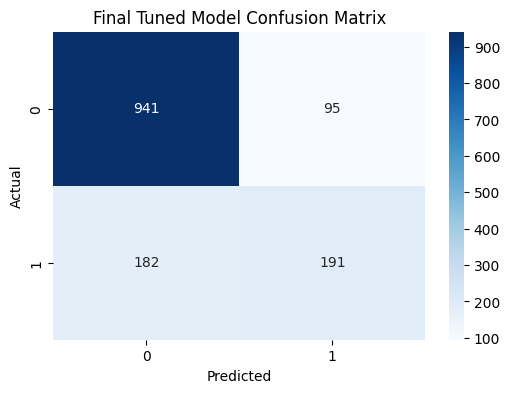

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Use RandomizedSearchCV for tuning
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30]
}

tuned_rf = RandomizedSearchCV(RandomForestClassifier(random_state=42),
                               param_distributions=param_dist,
                               n_iter=10, cv=3, random_state=42)

tuned_rf.fit(X_train, y_train)

# 2. Comparison
y_pred_tuned = tuned_rf.predict(X_test)
print("--- Tuned Model Results ---")
print(f"Best Parameters: {tuned_rf.best_params_}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_tuned):.4f}")

# Final Submission Requirement: Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_tuned), annot=True, fmt='d', cmap='Blues')
plt.title('Final Tuned Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()